In [1]:
import numpy as np
import pandas as pd
import matplotlib as mpl
import matplotlib.pyplot as plt
import scipy.optimize as spopt
import scipy.fftpack as spfft
import scipy.ndimage as spimg
import cvxpy as cvx

In [34]:
def read_data(filename):
    data = pd.read_csv(filename, sep = ",")
    data = data.to_numpy()*10**4
    return data

In [35]:
filename = '101_points.csv'
data = read_data(filename)

In [48]:
## Defining the signal and temporal space
num_sig = data.shape[1]
num_time_steps = data.shape[0]
time_step = 0.001
start_time = 0
end_time = time_step*num_timesteps
t = np.linspace(start_time, end_time,num_time_steps)

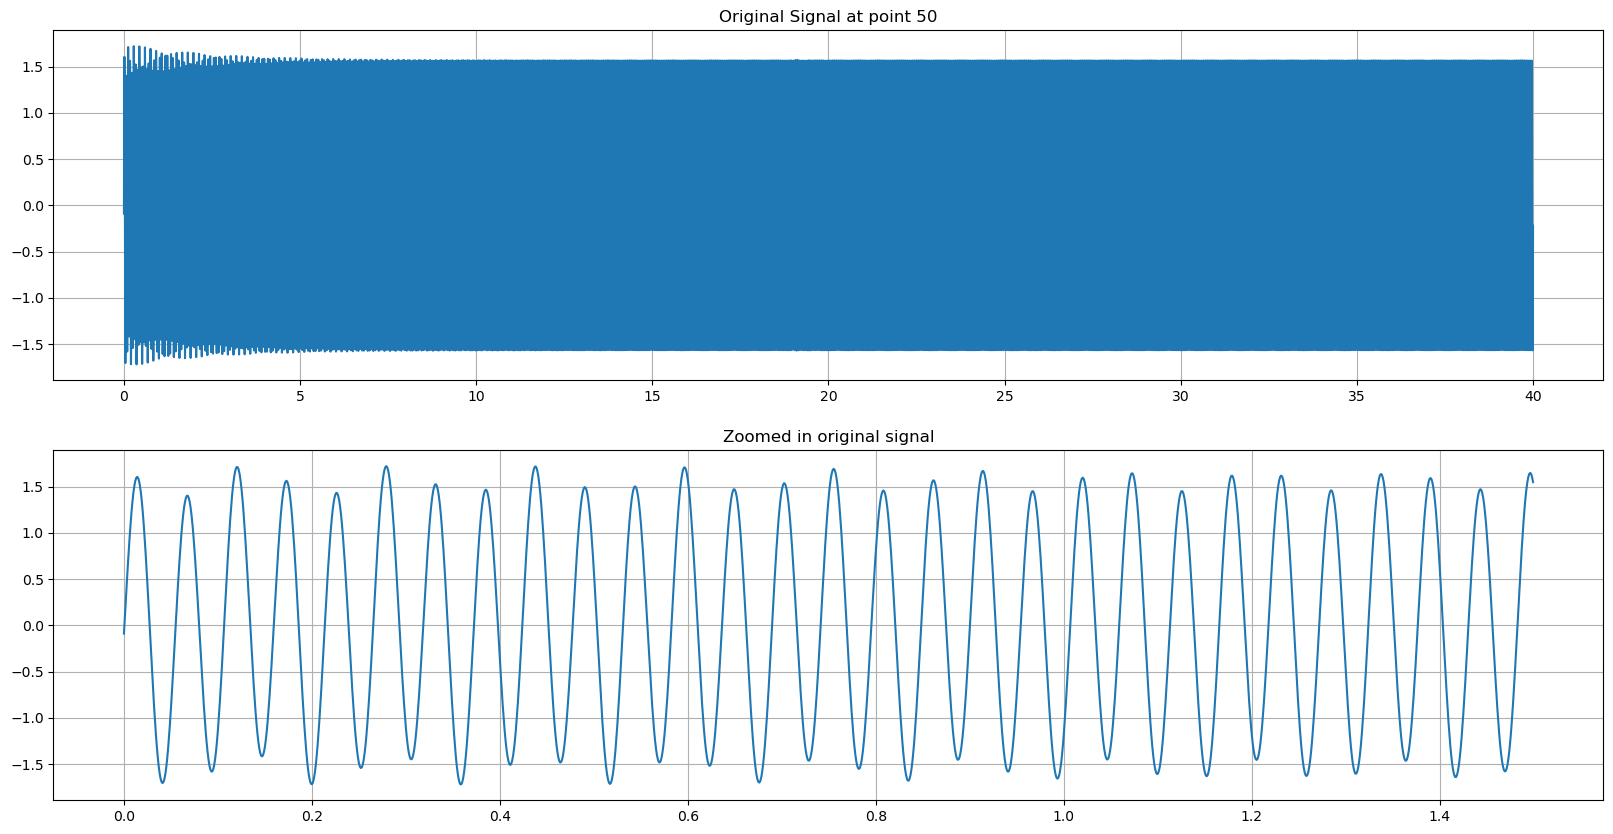

In [59]:
## Plotting the signals
sig_index = 50
zoom_lim = 1500
fig, axs = plt.subplots(2, figsize = (20,10))
axs[0].plot(t,data[:,sig_index])
axs[0].set_title("Original Signal at point " + str(sig_index))
axs[0].grid()
axs[1].plot(t[:zoom_lim],data[:zoom_lim,sig_index])
axs[1].set_title("Zoomed in original signal")
axs[1].grid()

In [60]:
## Truncating the signal
data2 = data[:5000,:]

(0.0, 0.5000125)

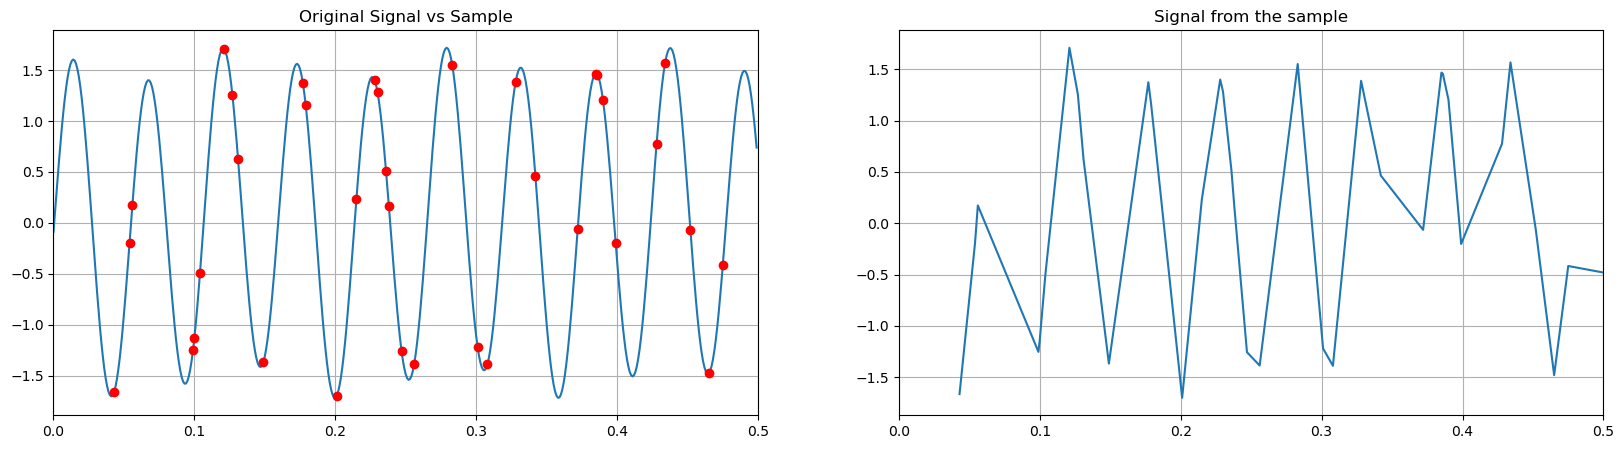

In [92]:
## Sampling the signal
samp = 300
samp_ind = np.random.choice(data2.shape[0], samp, replace = False)
samp_ind.sort()
t_cs = t[samp_ind]
y_cs = data2[samp_ind,sig_index]

fig, axs = plt.subplots(1,2, figsize = (20,5))
axs[0].plot(t[:500],data2[:500,sig_index])
axs[0].plot(t_cs,y_cs,'ro')
axs[0].set_xlim((0, t[500]))
axs[0].grid()
axs[0].set_title('Original Signal vs Sample')
axs[1].plot(t_cs,y_cs)
axs[1].grid()
axs[1].set_title('Signal from the sample')
axs[1].set_xlim((0, t[500]))

In [70]:
A_cs = spfft.idct(np.identity(5000), norm = 'ortho', axis = 0)
A_cs = A_cs[samp_ind]

vx = cvx.Variable(5000)
objective = cvx.Minimize(cvx.norm(vx,1))
constraints = [A_cs*vx == y_cs]
problem = cvx.Problem(objective, constraints)
result = problem.solve(verbose = False)

C:\Users\nippu\anaconda3\Lib\site-packages\cvxpy\expressions\expression.py:650: UserWarning: 
This use of ``*`` has resulted in matrix multiplication.
Using ``*`` for matrix multiplication has been deprecated since CVXPY 1.1.
    Use ``*`` for matrix-scalar and vector-scalar multiplication.
    Use ``@`` for matrix-matrix and matrix-vector multiplication.
    Use ``multiply`` for elementwise multiplication.
This code path has been hit 7 times so far.

  warnings.warn(msg, UserWarning)


In [71]:
x = np.array(vx.value)
x = np.squeeze(x)
sig = spfft.idct(x, norm = 'ortho', axis = 0)

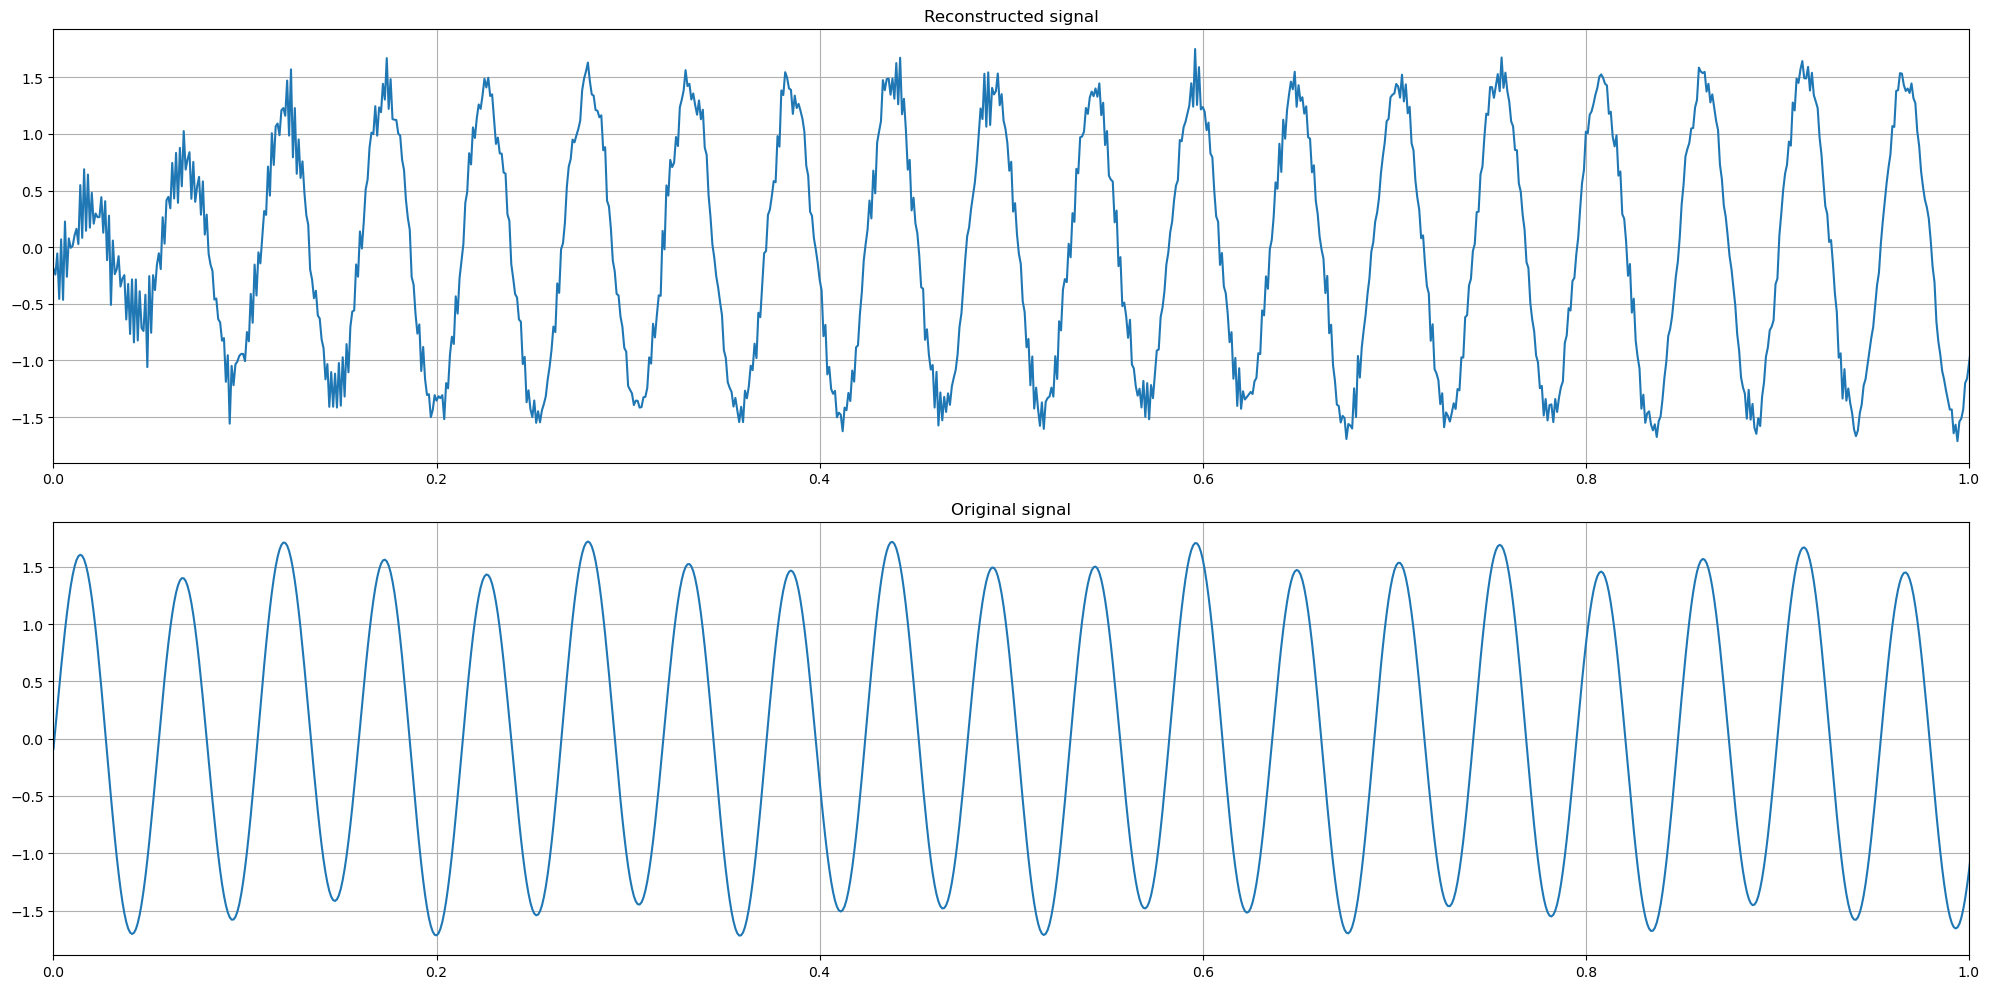

In [73]:
fig, axs = plt.subplots(2, figsize = (20,10))
axs[0].plot(t[:5000],sig)
axs[0].grid()
axs[0].set_xlim(0, t[1000])
axs[0].set_title('Reconstructed signal')
axs[1].plot(t[:5000],data2[:,sig_index])
axs[1].grid()
axs[1].set_xlim(0, t[1000])
axs[1].set_title('Original signal')
fig.tight_layout()

In [86]:
## System details
plt_index = 500
N = data.shape[1]
## Defining the x space
x_space = np.arange(data.shape[1])
## Sampling the signal I guess
samp = 50
samp_ind = np.random.choice(data.shape[1],samp, replace = False)
samp_ind.sort()
x_cs = x_space[samp_ind]
y_cs = data[500, samp_ind]


In [87]:
A_cs = spfft.idct(np.identity(N), norm = 'ortho', axis = 0)
A_cs = A_cs[samp_ind]

vx = cvx.Variable(N)
objective = cvx.Minimize(cvx.norm(vx,1))
constraints = [A_cs*vx == y_cs]
problem = cvx.Problem(objective, constraints)
result = problem.solve(verbose = False)

C:\Users\nippu\anaconda3\Lib\site-packages\cvxpy\expressions\expression.py:650: UserWarning: 
This use of ``*`` has resulted in matrix multiplication.
Using ``*`` for matrix multiplication has been deprecated since CVXPY 1.1.
    Use ``*`` for matrix-scalar and vector-scalar multiplication.
    Use ``@`` for matrix-matrix and matrix-vector multiplication.
    Use ``multiply`` for elementwise multiplication.
This code path has been hit 11 times so far.

  warnings.warn(msg, UserWarning)


In [88]:
x = np.array(vx.value)
x = np.squeeze(x)
sig = spfft.idct(x, norm = 'ortho', axis = 0)

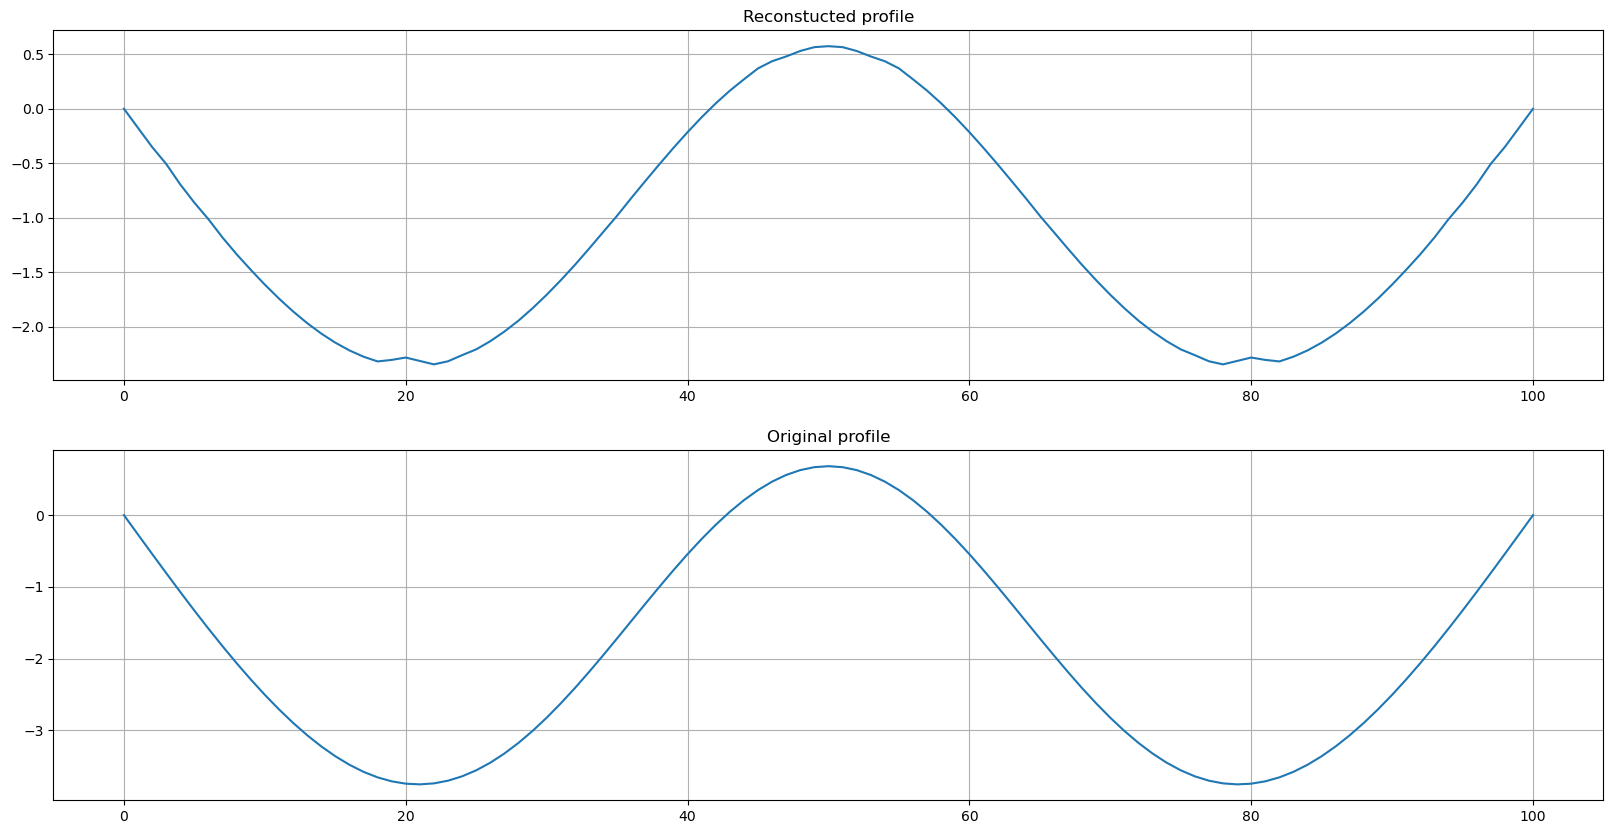

In [91]:
fig, axs = plt.subplots(2, figsize=(20,10))
axs[0].plot(x_space,sig)
axs[0].set_title('Reconstucted profile')
axs[0].grid()
axs[1].plot(np.arange(data.shape[1]),data[10005])
axs[1].set_title('Original profile')
axs[1].grid()